# Multi-object DP1 DCR workflow

This notebook scales the single-object workflow to many objects.

It does the following:
1. Runs a broad `dp1.Object` query with configurable magnitude limits.
2. For each object, fetches `dp1.Source` + `dp1.Visit`, builds the joined table, and computes `R45` by band.
3. Runs per-object processing in parallel.
4. Produces a table for trend analysis versus magnitude and color.

In [1]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

from astropy.table import join
from scipy.optimize import curve_fit, least_squares

from APIaccess import queryTAP
from utils import add_zenith_coordinates, parallactic_angle_from_radec_fast

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception:
    HAS_PANDAS = False

In [ ]:
# -----------------------------
# 1) Object query configuration
# -----------------------------

# Edit these to target different sky regions / object sets
# RA_MIN, RA_MAX = 52.8, 53.4
# DEC_MIN, DEC_MAX = -28.6, -27.9
RA_CENTER, DEC_CENTER = 53.0871733, -28.0878248,
SEARCH_RADIUS = 0.3

MAG_BAND = 'r'          # one of u,g,r,i,z,y
MAG_MIN = 18.0
MAG_MAX = 20.0
TOP_N_OBJECTS = 20     # upper cap for initial object query
REQUIRE_ISOLATED = False # detect_isIsolated = 1, this doesn't seem to work well
REQUIRE_CLEAN = False    # simple cut against obvious blends, also doesn't seem to work well

SNR = 20

# Choose R45 fitting method: 'complete' or 'naive'
# naive (fast): uses the median location of r and i band source detections as the true/unrefracted center
# complete (slow): fits for the true/unrefracted center location in addition to R45_{band}
FIT_METHOD = 'complete'


def build_object_query(
    RA_CENTER, DEC_CENTER, SEARCH_RADIUS,
    mag_band='r', mag_min=16.0, mag_max=22.0,
    top_n=300, require_isolated=True, require_clean=True, SNR=10
):
    """Build a configurable ADQL query to select a sample of DP1 objects.

    Parameters
    ----------
    RA_CENTER, DEC_CENTER : float
        Center of the sky region in degrees.
    SEARCH_RADIUS : float
        Cone-search radius in degrees.
    mag_band : str
        Band used for magnitude selection (u,g,r,i,z,y).
    mag_min, mag_max : float
        Magnitude limits for the chosen band.
    top_n : int
        Maximum number of objects to return.
    require_isolated, require_clean : bool
        Optional quality cuts.
    SNR : float
        Minimum g-band sersic flux SNR.
    """
    where = [
        f"g_sersicFlux/g_sersicFluxErr > {SNR}",
        f"CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {RA_CENTER}, {DEC_CENTER}, {SEARCH_RADIUS}))=1",
        f"{mag_band}_cModelMag BETWEEN {mag_min} AND {mag_max}",
        "sersic_no_data_flag = 0",  # check for good data
        "g_kronFlux_flag = 0",
        "g_cModel_flag = 0"
    ]

    if require_isolated:
        where.append("detect_isIsolated = 1")
    if require_clean:
        where.append("deblend_nChild = 0")

    where_clause = " AND ".join(where)

    query = f"""
    SELECT TOP {top_n}
        objectId, parentObjectId,
        coord_ra, coord_dec,
        tract, patch,
        refBand, refExtendedness, refSizeExtendedness,
        shape_xx, shape_xy, shape_yy,
        u_cModelMag, g_cModelMag, r_cModelMag, i_cModelMag, z_cModelMag, y_cModelMag
    FROM dp1.Object
    WHERE {where_clause}
    """
    return query


object_query = build_object_query(
    RA_CENTER, DEC_CENTER, SEARCH_RADIUS,
    mag_band=MAG_BAND, mag_min=MAG_MIN, mag_max=MAG_MAX,
    top_n=TOP_N_OBJECTS, require_isolated=REQUIRE_ISOLATED, require_clean=REQUIRE_CLEAN, SNR=SNR
)
print(f"Using fit method: {FIT_METHOD}")
print(object_query)
object_table = queryTAP(object_query)
print(f"Selected objects: {len(object_table)}")
object_table[:3]

Using fit method: complete

    SELECT TOP 20
        objectId, parentObjectId,
        coord_ra, coord_dec,
        tract, patch,
        refBand, refExtendedness, refSizeExtendedness,
        shape_xx, shape_xy, shape_yy,
        u_cModelMag, g_cModelMag, r_cModelMag, i_cModelMag, z_cModelMag, y_cModelMag
    FROM dp1.Object
    WHERE g_sersicFlux/g_sersicFluxErr > 20 AND CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', 53.0871733, -28.0878248, 0.3))=1 AND r_cModelMag BETWEEN 18.0 AND 20.0 AND sersic_no_data_flag = 0 AND g_kronFlux_flag = 0 AND g_cModel_flag = 0
    
Job phase is COMPLETED
Selected objects: 20


objectId,parentObjectId,coord_ra,coord_dec,tract,patch,refBand,refExtendedness,refSizeExtendedness,shape_xx,shape_xy,shape_yy,u_cModelMag,g_cModelMag,r_cModelMag,i_cModelMag,z_cModelMag,y_cModelMag
,,deg,deg,,,,,,pix2,pix2,pix2,mag,mag,mag,mag,mag,mag
int64,int64,float64,float64,int64,int64,str1,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
611254385447554307,611254385447538090,53.1040407510665,-28.04973429461265,5063,14,i,1.0,1.0,12.5879,2.09829,15.1156,21.9807,20.3471,19.4471,19.0613,18.8031,18.6703
611254385447553035,611254385447537833,53.171340423389914,-28.058517836586297,5063,14,i,1.0,1.0,11.1653,-1.72586,14.075,22.3577,20.1644,18.9688,18.5022,18.2472,18.0386
611254385447553698,611254385447537939,53.24690431920116,-28.05144703064306,5063,14,i,1.0,0.998204,7.67425,0.31207,10.7394,22.0306,20.2935,19.1035,18.6339,18.3766,18.189


In [ ]:
# -----------------------------------
# 2) Per-object calculation functions
# -----------------------------------

OBS_LAT = -30.244633
OBS_LON = -70.749417
OBS_HEIGHT = 2647

SEARCH_RADIUS_ARCSEC = 3.0
SNR_CUT = 10
CLIPPING_RADIUS_DEG = 1e-4


def safe_float(value):
    """Convert a value to float; return NaN when conversion fails."""
    try:
        return float(value)
    except Exception:
        return np.nan


def compute_dR_and_err(center_ra, center_dec, ra, dec, par, ra_err, dec_err, ra_dec_cov):
    """Compute altitude-direction residual offset (dR) and uncertainty per detection.

    Each source position offset from the trial center is rotated into the
    parallactic-angle frame; the altitude component is used as dR. Uncertainty
    is propagated via covariance rotation.

    Returns
    -------
    dR : np.ndarray
        Altitude-direction residuals in degrees.
    dR_err : np.ndarray
        1-sigma uncertainty on dR in degrees.
    finite_mask : np.ndarray[bool]
        True for rows with finite dR and positive finite uncertainty.
    """
    dR = np.zeros(len(ra))
    dR_err = np.zeros(len(ra))

    for i in range(len(ra)):
        cq, sq = np.cos(par[i]), np.sin(par[i])
        rot = np.array([[cq, -sq], [sq, cq]])

        dRA = (ra[i] - center_ra) * np.cos(dec[i] * np.pi / 180)
        dDec = dec[i] - center_dec
        _, dalt = rot @ np.array([[dRA, dDec]]).T
        dR[i] = dalt

        cov_matrix = np.array([[ra_err[i]**2, ra_dec_cov[i]],
                               [ra_dec_cov[i], dec_err[i]**2]])
        r_err_matrix = rot @ cov_matrix @ rot.T
        dR_err[i] = np.sqrt(np.abs(r_err_matrix[1, 1]))

    finite_mask = np.isfinite(dR) & np.isfinite(dR_err) & (dR_err > 0)
    return dR, dR_err, finite_mask


def fit_delta_r45_naive(master, snr_cut=10):
    """Fit per-band R45 using a fixed center estimated from detections.

    Strategy
    --------
    1) Apply SNR cut.
    2) Estimate unrefracted center from median (prefer r/i at low zenith distance).
    3) Compute dR and dR_err for each row.
    4) Fit R45 per band with weighted curve_fit to dR = R45 * tan(z).

    Returns
    -------
    (r45s, r45_errs, center_fit, center_fit_err, n_rows_used)
    """
    if snr_cut is not None:
        snr_mask = master['psfFlux'] / master['psfFluxErr'] >= snr_cut
        master = master[snr_mask]

    if len(master) == 0:
        raise ValueError('No rows available after SNR cut.')

    par = np.array(master['q'])
    ra = np.array(master['ra_1'])
    dec = np.array(master['dec_1'])
    ra_err = np.array(master['raErr'])
    dec_err = np.array(master['decErr'])
    ra_dec_cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band_1'])

    # Same center mask strategy as DCR_in_DP1 naive method
    center_mask = ((band_col == 'r') | (band_col == 'i')) & (zenith_distance < 20)
    if np.sum(center_mask) < 40:  # fallback if there are too few center-defining points
        center_mask = np.ones(len(master), dtype=bool)

    center_ra = np.median(ra[center_mask])
    center_dec = np.median(dec[center_mask])
    center_ra_err = np.std(ra[center_mask])
    center_dec_err = np.std(dec[center_mask])

    dR, dR_err, finite_mask = compute_dR_and_err(
        center_ra, center_dec, ra, dec, par, ra_err, dec_err, ra_dec_cov
    )

    def dR_model(z, r45):
        return r45 * np.tan(z * np.pi / 180)

    r45s = {}
    r45_errs = {}

    unique_bands = np.unique(band_col)
    for band in unique_bands:
        band_mask = (band_col == band) & finite_mask
        if np.sum(band_mask) < 2:
            continue

        popt, pcov = curve_fit(
            dR_model,
            zenith_distance[band_mask],
            dR[band_mask],
            sigma=dR_err[band_mask],
            p0=[0],
            absolute_sigma=True,
            maxfev=10000,
        )

        r45s[band] = popt[0]
        r45_errs[band] = np.sqrt(np.diag(pcov))[0]

    return r45s, r45_errs, (center_ra, center_dec), (center_ra_err, center_dec_err), len(master)


def fit_delta_r45_complete(master, snr_cut=10):
    """Jointly fit center coordinates and per-band R45 values.

    Unlike the naive approach, this solves for (center_ra, center_dec) together
    with one R45 parameter per band using nonlinear least squares. Weak Gaussian
    priors on center coordinates stabilize the solution.

    Returns
    -------
    (r45s, r45_errs, center_fit, center_fit_err, n_rows_used)
    """
    if snr_cut is not None:
        snr_mask = master['psfFlux'] / master['psfFluxErr'] >= snr_cut
        master = master[snr_mask]

    if len(master) == 0:
        raise ValueError('No rows available after SNR cut.')

    par = np.array(master['q'])
    ra = np.array(master['ra_1'])
    dec = np.array(master['dec_1'])
    ra_err = np.array(master['raErr'])
    dec_err = np.array(master['decErr'])
    ra_dec_cov = np.array(master['ra_dec_Cov'])
    zenith_distance = np.array(master['zenithDistance'])
    band_col = np.array(master['band_1'])

    center_ra0 = np.median(ra)
    center_dec0 = np.median(dec)
    center_ra_err0 = np.std(ra) / np.sqrt(len(ra))
    center_dec_err0 = np.std(dec) / np.sqrt(len(dec))

    center_ra_err0 = max(center_ra_err0, 1e-8)
    center_dec_err0 = max(center_dec_err0, 1e-8)

    unique_bands = np.unique(band_col)
    if len(unique_bands) == 0:
        raise ValueError('No valid bands for fitting.')

    band_to_index = {band: i for i, band in enumerate(unique_bands)}
    band_index = np.array([band_to_index[band] for band in band_col], dtype=int)

    dR0, dR_err0, finite_mask0 = compute_dR_and_err(
        center_ra0, center_dec0, ra, dec, par, ra_err, dec_err, ra_dec_cov
    )

    def dR_model(z, r45):
        return r45 * np.tan(z * np.pi / 180)

    # Initialize each band's R45 from independent weighted fits.
    r45_init = np.zeros(len(unique_bands))
    for j, band in enumerate(unique_bands):
        band_mask = (band_col == band) & finite_mask0
        if np.sum(band_mask) < 2:
            continue
        try:
            popt, _ = curve_fit(
                dR_model,
                zenith_distance[band_mask],
                dR0[band_mask],
                sigma=dR_err0[band_mask],
                p0=[0],
                absolute_sigma=True,
                maxfev=10000,
            )
            r45_init[j] = popt[0]
        except Exception:
            r45_init[j] = 0.0

    x0 = np.concatenate(([center_ra0, center_dec0], r45_init))

    def residuals(params):
        """Data residuals plus Gaussian prior residuals for center coordinates."""
        center_ra = params[0]
        center_dec = params[1]
        r45_vals = params[2:]

        dR, dR_err, finite_mask = compute_dR_and_err(
            center_ra, center_dec, ra, dec, par, ra_err, dec_err, ra_dec_cov
        )

        model = r45_vals[band_index] * np.tan(zenith_distance * np.pi / 180)
        data_resid = (dR - model) / dR_err
        data_resid = data_resid[finite_mask]

        prior_resid = np.array([
            (center_ra - center_ra0) / center_ra_err0,
            (center_dec - center_dec0) / center_dec_err0,
        ])

        return np.concatenate((data_resid, prior_resid))

    result = least_squares(residuals, x0, method='trf')

    best_params = result.x
    center_ra_fit, center_dec_fit = best_params[0], best_params[1]
    r45_fit = best_params[2:]

    n_resid = len(result.fun)
    n_param = len(best_params)
    dof = n_resid - n_param

    # Estimate parameter covariance from Jacobian at optimum.
    if dof > 0 and result.jac.size > 0:
        try:
            jacobian = result.jac
            cov = np.linalg.pinv(jacobian.T @ jacobian)
            chi2_red = 2 * result.cost / dof
            cov = cov * chi2_red
            param_err = np.sqrt(np.clip(np.diag(cov), 0, np.inf))
        except Exception:
            param_err = np.full(n_param, np.nan)
    else:
        param_err = np.full(n_param, np.nan)

    center_ra_fit_err, center_dec_fit_err = param_err[0], param_err[1]
    r45_fit_err = param_err[2:]

    r45s = {band: r45_fit[j] for j, band in enumerate(unique_bands)}
    r45_errs = {band: r45_fit_err[j] for j, band in enumerate(unique_bands)}

    return r45s, r45_errs, (center_ra_fit, center_dec_fit), (center_ra_fit_err, center_dec_fit_err), len(master)


def run_delta_r45_fit(master, method='complete', snr_cut=10):
    """Dispatch R45 fitting to either the naive or complete fitter."""
    method_key = str(method).strip().lower()

    if method_key == 'complete':
        return fit_delta_r45_complete(master, snr_cut=snr_cut)
    if method_key == 'naive':
        return fit_delta_r45_naive(master, snr_cut=snr_cut)

    raise ValueError("method must be 'complete' or 'naive'")


def query_sources_for_object(ra, dec, search_radius_arcsec=3.0):
    """Query DP1 Source rows around a target sky position."""
    source_query = f"""
    SELECT band, calibFlux, calibFluxErr,
           coord_dec, coord_ra, dec, decErr,
           ixx, ixxPSF, ixy, ixyPSF, iyy, iyyPSF,
           psfFlux, psfFluxErr, ra, raErr, ra_dec_Cov, visit
    FROM dp1.Source
    WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
                   CIRCLE('ICRS', {ra}, {dec}, {search_radius_arcsec/3600}))=1
    """
    return queryTAP(source_query)


def query_visits_for_sources(source_table):
    """Query DP1 Visit metadata for the set of visits present in source_table."""
    visits = np.unique(source_table['visit'])
    visit_string = "','".join(map(str, visits))

    visit_query = f"""
    SELECT airmass, altitude, azimuth, band, dec, expTime, ra, skyRotation,
           visit, zenithDistance, expMidptMJD
    FROM dp1.Visit
    WHERE visit IN ('{visit_string}')
    """
    return queryTAP(visit_query)


def process_single_object(obj_row,
                          search_radius_arcsec=SEARCH_RADIUS_ARCSEC,
                          snr_cut=SNR_CUT,
                          clipping_radius_deg=CLIPPING_RADIUS_DEG,
                          fit_method='complete'):
    """Run the full DCR fit pipeline for one object row from dp1.Object.

    Steps
    -----
    1) Query Source and Visit tables.
    2) Join, de-duplicate, clip outliers, and apply covariance corrections.
    3) Add zenith/parallactic quantities.
    4) Fit R45 values (naive or complete method).

    Returns
    -------
    dict
        Flat summary with object metadata, fit results, uncertainties, row counts,
        and status.
    """
    object_id = int(obj_row['objectId'])
    ra_obj = safe_float(obj_row['coord_ra'])
    dec_obj = safe_float(obj_row['coord_dec'])

    result = {
        'objectId': object_id,
        'coord_ra': ra_obj,
        'coord_dec': dec_obj,
        'u_cModelMag': safe_float(obj_row['u_cModelMag']),
        'g_cModelMag': safe_float(obj_row['g_cModelMag']),
        'r_cModelMag': safe_float(obj_row['r_cModelMag']),
        'i_cModelMag': safe_float(obj_row['i_cModelMag']),
        'z_cModelMag': safe_float(obj_row['z_cModelMag']),
        'y_cModelMag': safe_float(obj_row['y_cModelMag']),
        'g_minus_r': safe_float(obj_row['g_cModelMag']) - safe_float(obj_row['r_cModelMag']),
        'r_minus_i': safe_float(obj_row['r_cModelMag']) - safe_float(obj_row['i_cModelMag']),
        'fit_method': fit_method,
        'status': 'ok',
        'n_source_rows': 0,
        'n_fit_rows': 0,
    }

    for band in 'ugrizy':
        result[f'R45_{band}'] = np.nan
        result[f'R45err_{band}'] = np.nan

    try:
        source_table = query_sources_for_object(ra_obj, dec_obj, search_radius_arcsec=search_radius_arcsec)
        result['n_source_rows'] = len(source_table)

        if len(source_table) < 4:
            result['status'] = 'too_few_sources'
            return result

        visit_ids = np.array(source_table['visit'])
        vals, counts = np.unique(visit_ids, return_counts=True)
        duplicates = vals[counts > 1]
        if len(duplicates) > 0:
            source_mask = np.isin(source_table['visit'], duplicates)
            source_table = source_table[~source_mask]

        if len(source_table) < 4:
            result['status'] = 'too_few_sources_after_dedup'
            return result

        visit_table = query_visits_for_sources(source_table)
        if len(visit_table) == 0:
            result['status'] = 'no_visits'
            return result

        master_all = join(source_table, visit_table, keys='visit')
        if len(master_all) < 4:
            result['status'] = 'too_few_joined_rows'
            return result

        center_ra = np.median(master_all['ra_1'])
        center_dec = np.median(master_all['dec_1'])

        clip_mask = ((master_all['ra_1'] - center_ra)**2 + (master_all['dec_1'] - center_dec)**2) < (clipping_radius_deg**2)
        master = master_all[clip_mask]

        if len(master) < 4:
            result['status'] = 'too_few_rows_after_clip'
            return result

        correction = np.cos(np.array(master['dec_1']) * np.pi / 180)
        correction = np.where(np.abs(correction) < 1e-8, 1e-8, correction)
        master['raErr'] = np.array(master['raErr']) / correction
        master['ra_dec_Cov'] = np.array(master['ra_dec_Cov']) / correction

        master = add_zenith_coordinates(master, lat=OBS_LAT, lon=OBS_LON, height=OBS_HEIGHT)
        master = parallactic_angle_from_radec_fast(master, lat=OBS_LAT, lon=OBS_LON, height=OBS_HEIGHT)

        r45s, r45_errs, center_fit, center_fit_err, n_fit_rows = run_delta_r45_fit(
            master,
            method=fit_method,
            snr_cut=snr_cut,
        )

        result['n_fit_rows'] = n_fit_rows
        result['center_ra_fit'] = center_fit[0]
        result['center_dec_fit'] = center_fit[1]
        result['center_ra_fit_err'] = center_fit_err[0]
        result['center_dec_fit_err'] = center_fit_err[1]

        for band in 'ugrizy':
            if band in r45s:
                result[f'R45_{band}'] = r45s[band]
                result[f'R45err_{band}'] = r45_errs.get(band, np.nan)

        return result

    except Exception as err:
        result['status'] = f'error: {type(err).__name__}'
        return result

In [21]:
# ---------------------------------------------
# 3) Parallel execution over many selected objects
# ---------------------------------------------

MAX_OBJECTS_TO_RUN = 200   # set None to run all selected objects
MAX_WORKERS = 4            # increase carefully; each worker submits TAP jobs

objects_to_run = object_table if MAX_OBJECTS_TO_RUN is None else object_table[:MAX_OBJECTS_TO_RUN]
print(f'Running {len(objects_to_run)} objects with {MAX_WORKERS} workers...')
print(f'Fit method: {FIT_METHOD}')

results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    future_map = {
        pool.submit(process_single_object, row, fit_method=FIT_METHOD): int(row['objectId'])
        for row in objects_to_run
    }

    for index, future in enumerate(as_completed(future_map), start=1):
        results.append(future.result())
        if index % 20 == 0 or index == len(future_map):
            print(f'Completed {index}/{len(future_map)} objects')

if HAS_PANDAS:
    results_df = pd.DataFrame(results)
    display(results_df.head())
else:
    from astropy.table import Table
    results_df = Table(rows=results)
    results_df[:5]

# Complete method: ~3 min per 20 jobs with 4 workers
# Naive method: ~1 min per 20 jobs with 4 workers


Running 20 objects with 4 workers...
Fit method: complete
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_29177/1701810357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_29177/1701810357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from y

Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_29177/1701810357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


Job phase is COMPLETED
Job phase is COMPLETED
Job phase is COMPLETED


...

/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_29177/1701810357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


Job phase isJob phase is COMPLETED
 COMPLETED
Job phase isJob phase is COMPLETED
 COMPLETED


/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/opt/miniconda3/envs/DESC_DCR/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_29177/1701810357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dR[i] = dalt


Completed 20/20 objects


,objectId,coord_ra,coord_dec,u_cModelMag,g_cModelMag,r_cModelMag,i_cModelMag,z_cModelMag,y_cModelMag,g_minus_r,...,R45_i,R45err_i,R45_z,R45err_z,R45_y,R45err_y,center_ra_fit,center_dec_fit,center_ra_fit_err,center_dec_fit_err
0,611254316728077585,53.392898,-28.037759,22.184999,19.909201,18.681999,17.482300,16.945299,16.674601,1.227201,...,2.120778e-06,1.130114e-06,3.942053e-07,1.043236e-06,6.678263e-07,0.000009,53.392895,-28.037757,2.769253e-07,2.362637e-06
1,611254385447554307,53.104041,-28.049734,21.980700,20.347099,19.447100,19.061300,18.803101,18.670300,0.900000,...,1.272204e-06,8.881288e-07,-2.844633e-06,1.264773e-06,3.550661e-06,0.000005,53.104038,-28.049737,2.031101e-07,3.172036e-07
2,611254385447553698,53.246904,-28.051447,22.030600,20.293501,19.103500,18.633900,18.376600,18.188999,1.190001,...,3.250261e-07,4.218432e-07,-7.052840e-07,6.291153e-07,3.913112e-07,0.000003,53.246905,-28.051449,1.423396e-07,3.654016e-07
3,611254385447553035,53.171340,-28.058518,22.357700,20.164400,18.968800,18.502199,18.247200,18.038601,1.195601,...,2.213882e-07,6.540620e-07,-2.372624e-06,9.976319e-07,-4.516422e-06,0.000005,53.171339,-28.058521,2.051944e-07,3.562789e-07
4,611254385447553526,53.104278,-28.027590,22.187201,20.496300,19.526300,19.060499,18.764900,18.588600,0.969999,...,4.808433e-07,8.138447e-07,-6.650076e-07,1.163714e-06,3.344507e-06,0.000005,53.104277,-28.027594,2.053494e-07,3.917719e-07


In [24]:
# ----------------------------------------------------
# 4) Lightweight trend summaries (no per-object plots)
# ----------------------------------------------------

if HAS_PANDAS:
    print(results_df['status'].value_counts())

    ok = results_df[results_df['status'] == 'ok'].copy()
    print(f'Usable objects: {len(ok)}')

    for band in 'ugrizy':
        col = f'R45_{band}'
        subset = ok[[col, 'r_cModelMag', 'g_minus_r']].replace([np.inf, -np.inf], np.nan).dropna()
        if len(subset) < 8:
            print(f'{band}: insufficient points for correlation')
            continue

        corr_mag = np.corrcoef(subset[col], subset['r_cModelMag'])[0, 1]
        corr_color = np.corrcoef(subset[col], subset['g_minus_r'])[0, 1]
        print(f'{band}: corr(R45, rMag)={corr_mag:.3f}, corr(R45, g-r)={corr_color:.3f}, N={len(subset)}')

    # Optional save for later analysis
    # results_df.to_csv('many_object_R45_results.csv', index=False)
else:
    print('Pandas not available. Use astropy table methods for summaries.')
    print(results_df[:10])

status
ok    20
Name: count, dtype: int64
Usable objects: 20
u: corr(R45, rMag)=0.338, corr(R45, g-r)=-0.410, N=14
g: corr(R45, rMag)=0.048, corr(R45, g-r)=-0.685, N=20
r: corr(R45, rMag)=0.007, corr(R45, g-r)=-0.414, N=20
i: corr(R45, rMag)=0.118, corr(R45, g-r)=0.169, N=20
z: corr(R45, rMag)=0.319, corr(R45, g-r)=0.329, N=20
y: corr(R45, rMag)=0.310, corr(R45, g-r)=-0.227, N=20


Objects in summary plots: 20


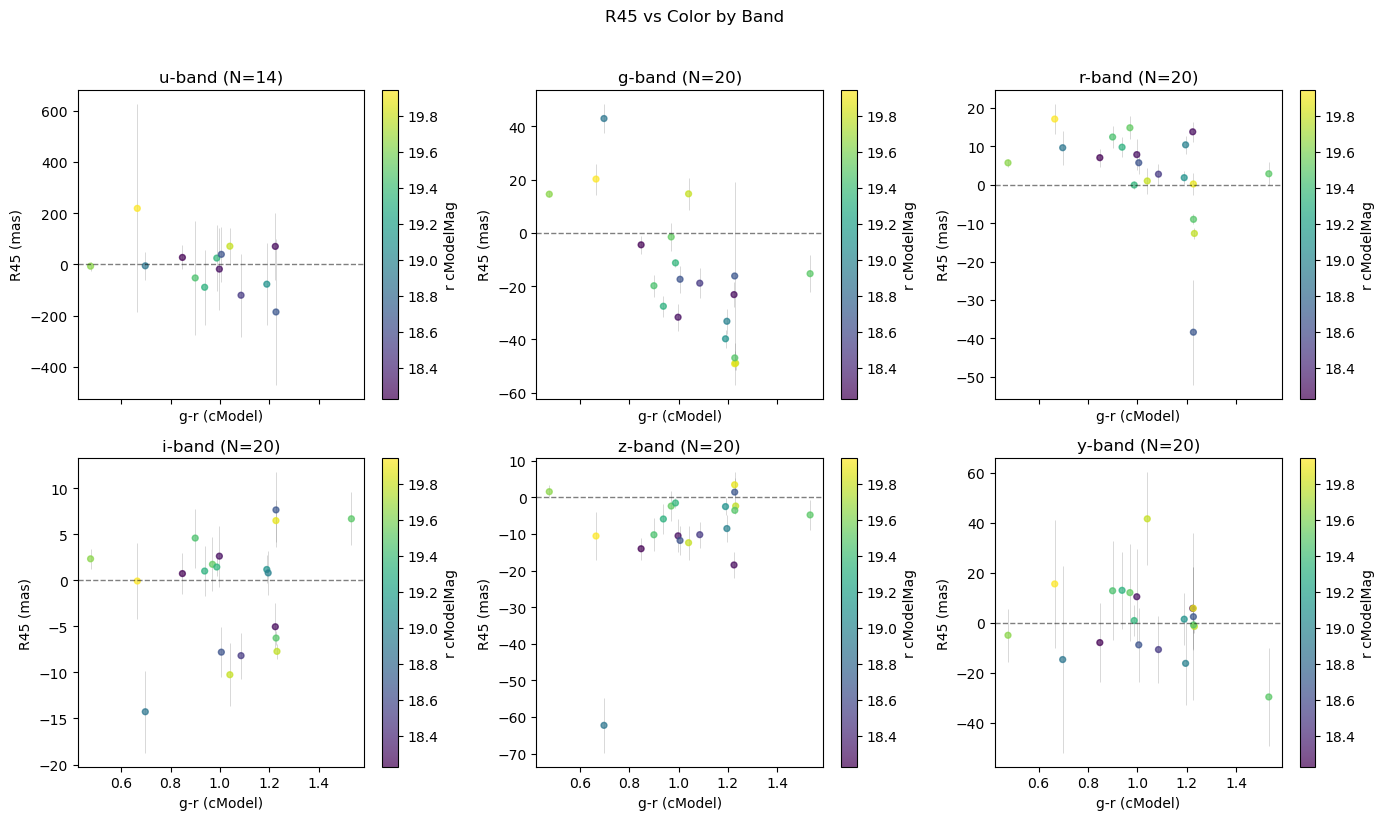

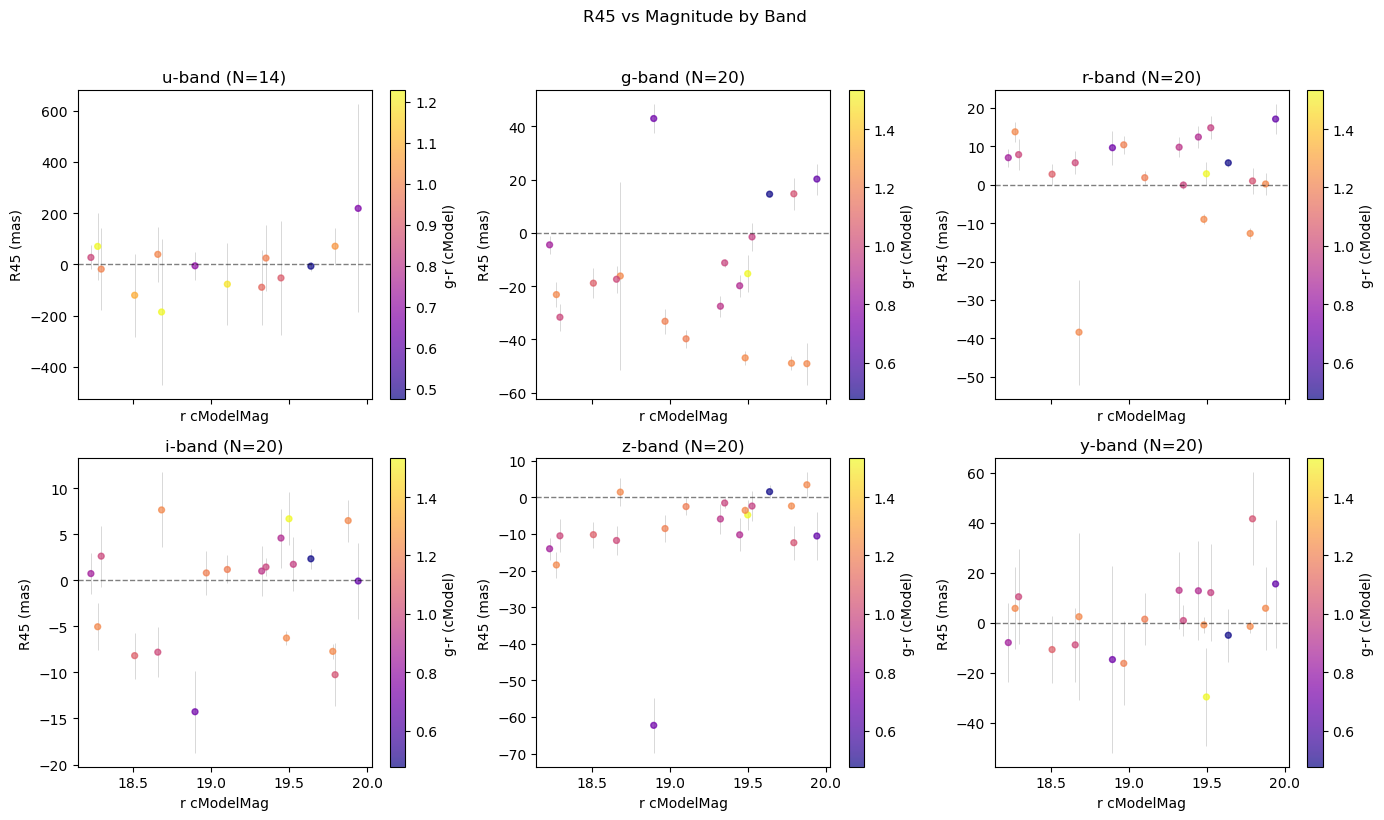

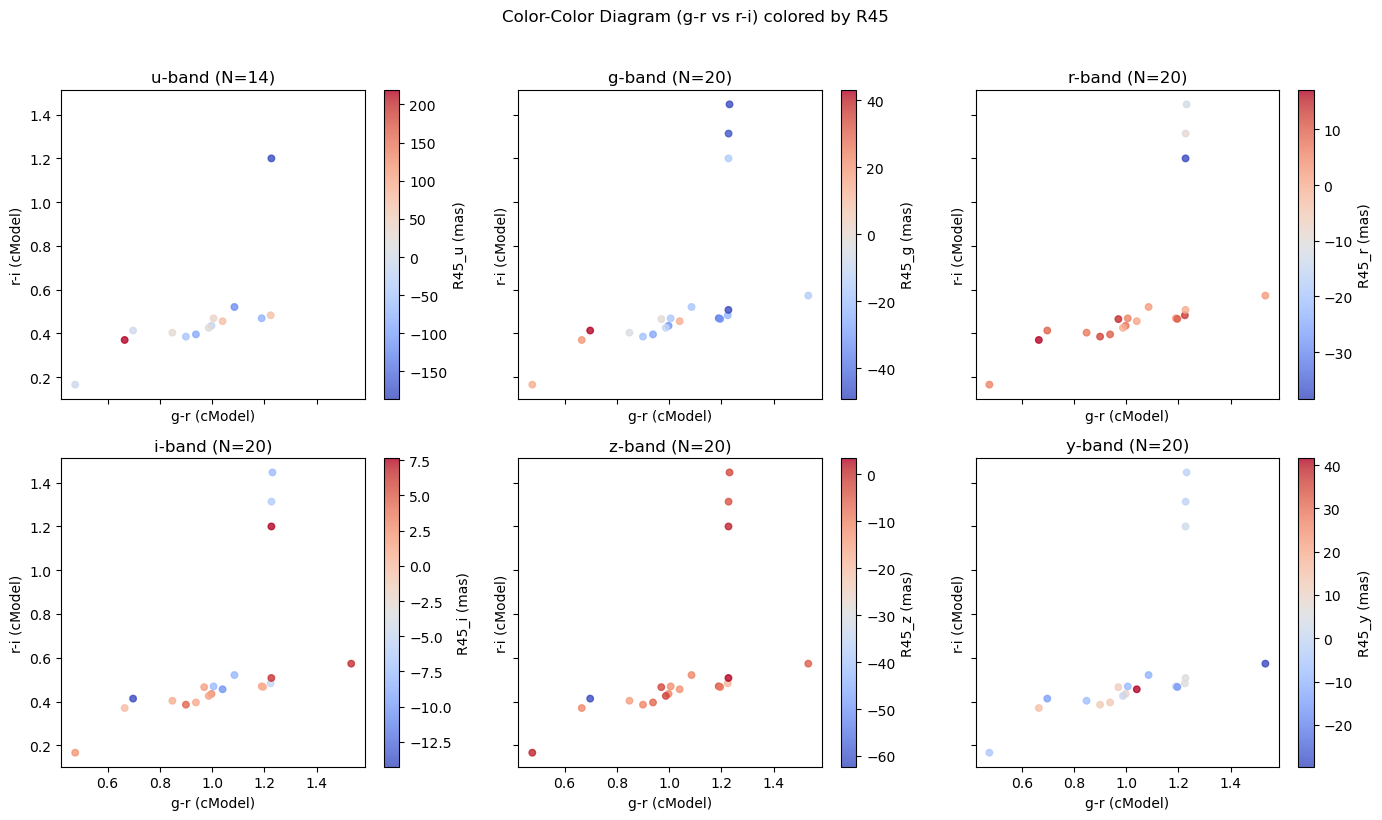

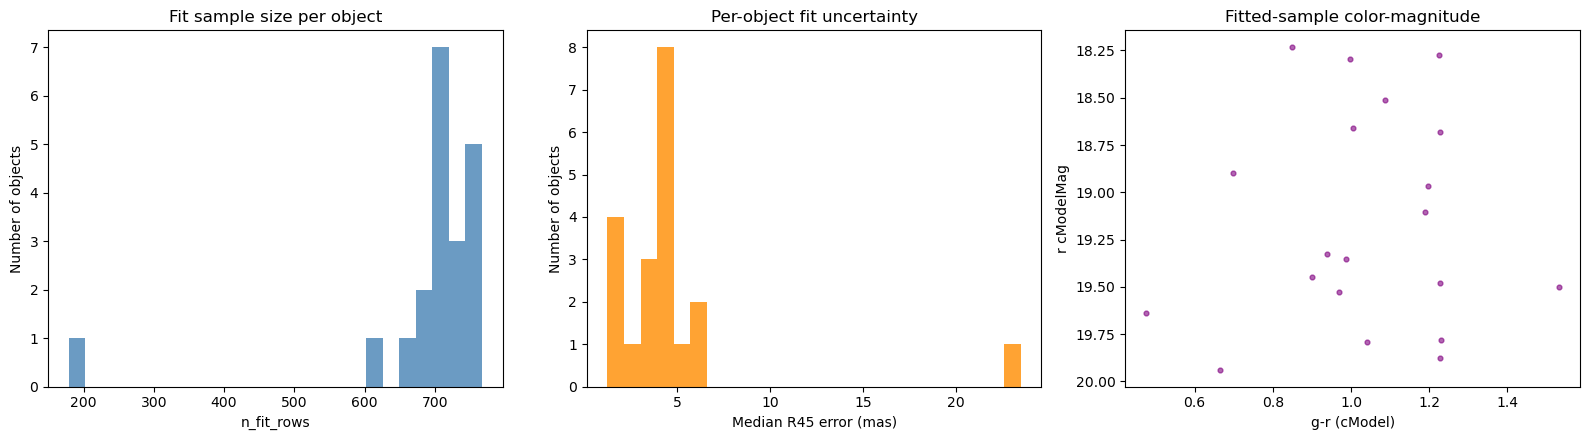


Correlation summary (Pearson):
  u: corr(R45, rMag)=0.338, corr(R45, g-r)=-0.410, N=14
  g: corr(R45, rMag)=0.048, corr(R45, g-r)=-0.685, N=20
  r: corr(R45, rMag)=0.007, corr(R45, g-r)=-0.414, N=20
  i: corr(R45, rMag)=0.118, corr(R45, g-r)=0.169, N=20
  z: corr(R45, rMag)=0.319, corr(R45, g-r)=0.329, N=20
  y: corr(R45, rMag)=0.310, corr(R45, g-r)=-0.227, N=20


In [25]:
# Summary plots: relationships between R45, magnitude, color, and quality metrics

import numpy as np
import matplotlib.pyplot as plt

if not HAS_PANDAS:
    print('Pandas not available in this kernel; convert results to pandas to use this plotting cell.')
else:
    df = results_df.copy()

    # Keep only successful fits
    df = df[df['status'] == 'ok'].copy()

    # Convert R45 and R45err to milliarcseconds for readability
    for band in 'ugrizy':
        r_col = f'R45_{band}'
        e_col = f'R45err_{band}'
        if r_col in df.columns:
            df[f'R45_{band}_mas'] = df[r_col] * 3600 * 1000
        if e_col in df.columns:
            df[f'R45err_{band}_mas'] = df[e_col] * 3600 * 1000

    # Keep rows with at least one finite R45 measurement
    r45_cols_mas = [f'R45_{b}_mas' for b in 'ugrizy' if f'R45_{b}_mas' in df.columns]
    if len(r45_cols_mas) == 0:
        print('No R45 columns found to plot.')
    else:
        finite_any = np.isfinite(df[r45_cols_mas]).any(axis=1)
        df = df[finite_any].copy()

        print(f'Objects in summary plots: {len(df)}')

        # ---------------------------------
        # 1) R45 vs color (g-r), by band
        # ---------------------------------
        fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
        axes = axes.ravel()

        for i, band in enumerate('ugrizy'):
            ax = axes[i]
            r_col = f'R45_{band}_mas'
            e_col = f'R45err_{band}_mas'
            if r_col not in df.columns:
                ax.set_visible(False)
                continue

            plot_cols = ['g_minus_r', r_col, 'r_cModelMag']
            if e_col in df.columns:
                plot_cols.append(e_col)

            sub = df[plot_cols].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) < 5:
                ax.set_title(f'{band}-band (N<5)')
                continue

            if e_col in sub.columns:
                ax.errorbar(
                    sub['g_minus_r'],
                    sub[r_col],
                    yerr=sub[e_col],
                    fmt='none',
                    ecolor='gray',
                    elinewidth=0.6,
                    alpha=0.35,
                    zorder=1,
                )

            sc = ax.scatter(
                sub['g_minus_r'],
                sub[r_col],
                c=sub['r_cModelMag'],
                s=18,
                alpha=0.7,
                cmap='viridis',
                zorder=2,
            )
            ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            ax.set_title(f'{band}-band (N={len(sub)})')
            ax.set_xlabel('g-r (cModel)')
            ax.set_ylabel('R45 (mas)')
            cb = plt.colorbar(sc, ax=ax)
            cb.set_label('r cModelMag')

        plt.suptitle('R45 vs Color by Band', y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------------------------------
        # 2) R45 vs magnitude (r-band mag)
        # ---------------------------------
        fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
        axes = axes.ravel()

        for i, band in enumerate('ugrizy'):
            ax = axes[i]
            r_col = f'R45_{band}_mas'
            e_col = f'R45err_{band}_mas'
            if r_col not in df.columns:
                ax.set_visible(False)
                continue

            plot_cols = ['r_cModelMag', r_col, 'g_minus_r']
            if e_col in df.columns:
                plot_cols.append(e_col)

            sub = df[plot_cols].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) < 5:
                ax.set_title(f'{band}-band (N<5)')
                continue

            if e_col in sub.columns:
                ax.errorbar(
                    sub['r_cModelMag'],
                    sub[r_col],
                    yerr=sub[e_col],
                    fmt='none',
                    ecolor='gray',
                    elinewidth=0.6,
                    alpha=0.35,
                    zorder=1,
                )

            sc = ax.scatter(
                sub['r_cModelMag'],
                sub[r_col],
                c=sub['g_minus_r'],
                s=18,
                alpha=0.7,
                cmap='plasma',
                zorder=2,
            )
            ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            ax.set_title(f'{band}-band (N={len(sub)})')
            ax.set_xlabel('r cModelMag')
            ax.set_ylabel('R45 (mas)')
            cb = plt.colorbar(sc, ax=ax)
            cb.set_label('g-r (cModel)')

        plt.suptitle('R45 vs Magnitude by Band', y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------------------------------
        # 3) Color-color diagram, colored by R45
        # ---------------------------------
        fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
        axes = axes.ravel()

        for i, band in enumerate('ugrizy'):
            ax = axes[i]
            r_col = f'R45_{band}_mas'
            if r_col not in df.columns:
                ax.set_visible(False)
                continue

            sub = df[['g_minus_r', 'r_minus_i', r_col]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) < 5:
                ax.set_title(f'{band}-band (N<5)')
                continue

            sc = ax.scatter(
                sub['g_minus_r'],
                sub['r_minus_i'],
                c=sub[r_col],
                s=22,
                alpha=0.8,
                cmap='coolwarm',
            )
            ax.set_title(f'{band}-band (N={len(sub)})')
            ax.set_xlabel('g-r (cModel)')
            ax.set_ylabel('r-i (cModel)')
            cb = plt.colorbar(sc, ax=ax)
            cb.set_label(f'R45_{band} (mas)')

        plt.suptitle('Color-Color Diagram (g-r vs r-i) colored by R45', y=1.02)
        plt.tight_layout()
        plt.show()

        # ---------------------------------
        # 4) Quality / diagnostics summary
        # ---------------------------------
        fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

        # Number of fitted points per object
        if 'n_fit_rows' in df.columns:
            ax[0].hist(df['n_fit_rows'].dropna(), bins=25, color='steelblue', alpha=0.8)
            ax[0].set_xlabel('n_fit_rows')
            ax[0].set_ylabel('Number of objects')
            ax[0].set_title('Fit sample size per object')

        # Median R45 uncertainty (across bands) per object
        err_cols = [f'R45err_{b}_mas' for b in 'ugrizy' if f'R45err_{b}_mas' in df.columns]
        if len(err_cols) > 0:
            df['median_R45err_mas'] = df[err_cols].median(axis=1, skipna=True)
            ax[1].hist(df['median_R45err_mas'].dropna(), bins=25, color='darkorange', alpha=0.8)
            ax[1].set_xlabel('Median R45 error (mas)')
            ax[1].set_ylabel('Number of objects')
            ax[1].set_title('Per-object fit uncertainty')

        # Color-magnitude diagram for fitted sample
        if {'r_cModelMag', 'g_minus_r'}.issubset(df.columns):
            sub = df[['r_cModelMag', 'g_minus_r']].replace([np.inf, -np.inf], np.nan).dropna()
            ax[2].scatter(sub['g_minus_r'], sub['r_cModelMag'], s=12, alpha=0.6, color='purple')
            ax[2].invert_yaxis()
            ax[2].set_xlabel('g-r (cModel)')
            ax[2].set_ylabel('r cModelMag')
            ax[2].set_title('Fitted-sample color-magnitude')

        plt.tight_layout()
        plt.show()

        # Optional: quick correlation summary table by band
        print('\nCorrelation summary (Pearson):')
        for band in 'ugrizy':
            r_col = f'R45_{band}_mas'
            if r_col not in df.columns:
                continue
            sub = df[[r_col, 'r_cModelMag', 'g_minus_r']].replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) < 8:
                print(f'  {band}: insufficient points')
                continue
            corr_mag = np.corrcoef(sub[r_col], sub['r_cModelMag'])[0, 1]
            corr_color = np.corrcoef(sub[r_col], sub['g_minus_r'])[0, 1]
            print(f'  {band}: corr(R45, rMag)={corr_mag:.3f}, corr(R45, g-r)={corr_color:.3f}, N={len(sub)}')